# 数据集预处理
针对单个数据集进行严格的：
- 设置随机种子
- 样本筛选
- 细胞质控
- 去除环境污染（是否需要？）
- 保存质控后数据至'UC/scRNA-seq_data/03_qc_filtered'文件夹
- 批次效应查看
- 降维聚类结果
- 处理异常细胞群
- 区分主要谱系

# 文件说明
- **文件名**: 1_GSE182270_qc.h5ad 
- **存放位置**: 坚果云  `UC/scRNA-seq_data/03_qc_filtered/`  
- **生成日期**: 2025-11-3  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/1.2_qc_filtered/1_GSE182270.ipynb  
- **内容说明**: 完成了针对单个数据的预处理工作，包括样本排除、细胞质控，并查看了样本间的批次效应。  

In [28]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)

In [29]:
import scanpy as sc
#sc.settings.verbosity = 1
print(sc.__version__)

1.11.4


## 读取数据
GSE182270数据集：
- 结肠组织细胞
- 4UC，4HC

In [30]:
adata = sc.read_h5ad('/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/02_sample_merge/1_GSE182270.h5ad')

In [31]:
adata

AnnData object with n_obs × n_vars = 30896 × 15077
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells'
    uns: 'REFERENCE_MANU', 'scrublet', 'status', 'status_args'

In [32]:
adata.obs.head()

,n_genes,GSM_id,GSM,id,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet
GSM5525955_UC1_AAACCTGAGAGACTAT-1,1239,GSM5525955_UC1,GSM5525955,UC1,2899.0,0.034150,1239,0.427389,True,True,True,0.020859,False
GSM5525955_UC1_AAACCTGAGGCCGAAT-1,3996,GSM5525955_UC1,GSM5525955,UC1,16359.0,0.042423,3996,0.244269,True,True,True,0.166313,False
GSM5525955_UC1_AAACCTGAGGCTCATT-1,2758,GSM5525955_UC1,GSM5525955,UC1,13663.0,0.045598,2758,0.201859,True,True,True,0.066212,False
GSM5525955_UC1_AAACCTGCATAAAGGT-1,1791,GSM5525955_UC1,GSM5525955,UC1,5845.0,0.031822,1791,0.306416,True,True,True,0.088000,False
GSM5525955_UC1_AAACCTGCATATGAGA-1,1270,GSM5525955_UC1,GSM5525955,UC1,2797.0,0.028245,1270,0.454058,True,True,True,0.062808,False


## 处理细胞标签及分组

In [33]:
# 提取分组信息
import pandas as pd
adata.obs['group'] = adata.obs['id'].str.extract(r'([A-Za-z]+)', expand=False)
print(adata.obs[['id', 'group']].head())

                                    id group
GSM5525955_UC1_AAACCTGAGAGACTAT-1  UC1    UC
GSM5525955_UC1_AAACCTGAGGCCGAAT-1  UC1    UC
GSM5525955_UC1_AAACCTGAGGCTCATT-1  UC1    UC
GSM5525955_UC1_AAACCTGCATAAAGGT-1  UC1    UC
GSM5525955_UC1_AAACCTGCATATGAGA-1  UC1    UC


`.obs`当中只保留GSM信息和分组信息

In [34]:
adata.obs.drop(columns=['GSM_id', 'id'], inplace=True)
print(adata.obs.head())

                                   n_genes         GSM    nUMIs  mito_perc  \
GSM5525955_UC1_AAACCTGAGAGACTAT-1     1239  GSM5525955   2899.0   0.034150   
GSM5525955_UC1_AAACCTGAGGCCGAAT-1     3996  GSM5525955  16359.0   0.042423   
GSM5525955_UC1_AAACCTGAGGCTCATT-1     2758  GSM5525955  13663.0   0.045598   
GSM5525955_UC1_AAACCTGCATAAAGGT-1     1791  GSM5525955   5845.0   0.031822   
GSM5525955_UC1_AAACCTGCATATGAGA-1     1270  GSM5525955   2797.0   0.028245   

                                   detected_genes  cell_complexity  \
GSM5525955_UC1_AAACCTGAGAGACTAT-1            1239         0.427389   
GSM5525955_UC1_AAACCTGAGGCCGAAT-1            3996         0.244269   
GSM5525955_UC1_AAACCTGAGGCTCATT-1            2758         0.201859   
GSM5525955_UC1_AAACCTGCATAAAGGT-1            1791         0.306416   
GSM5525955_UC1_AAACCTGCATATGAGA-1            1270         0.454058   

                                   passing_mt  passing_nUMIs  passing_ngenes  \
GSM5525955_UC1_AAACCTGAGAGACTA

In [35]:
adata.obs['group'].value_counts()

group
UC    17826
HC    13070
Name: count, dtype: int64

## 样本质量查看

In [36]:
adata.obs['GSM'].value_counts()

GSM
GSM5525963    5404
GSM5525957    5320
GSM5525955    4755
GSM5525959    4036
GSM5525962    3098
GSM5525960    2995
GSM5525961    2941
GSM5525956    2347
Name: count, dtype: int64

In [37]:
sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])

print(sample_quality_stats)

                n_genes                               nUMIs               \
                   mean         std  min   max         mean          std   
GSM                                                                        
GSM5525955  1481.498002  726.891760  329  6608  8175.273926  4837.471191   
GSM5525956  1506.438858  832.734897  283  5994  8890.578125  7289.617676   
GSM5525957  1184.234398  566.067664  257  5789  6296.655762  4006.980469   
GSM5525959  1212.905352  487.273174  391  6978  7082.444824  5440.171387   
GSM5525960  1204.531553  497.794390  294  5672  8243.652344  6316.874023   
GSM5525961  1023.217613  400.373525  258  5091  6486.574707  4807.651855   
GSM5525962  1294.885733  643.717311  251  5554  6426.551270  6484.558105   
GSM5525963  1281.411547  810.495421  251  8501  7206.620117  8708.438477   

                             mito_perc                                
               min       max      mean       std       min       max  
GSM                  

注意到最后两个数据集的线粒体比例有些异常：`GSM5525962`, `GSM5525963`

## 细胞质控

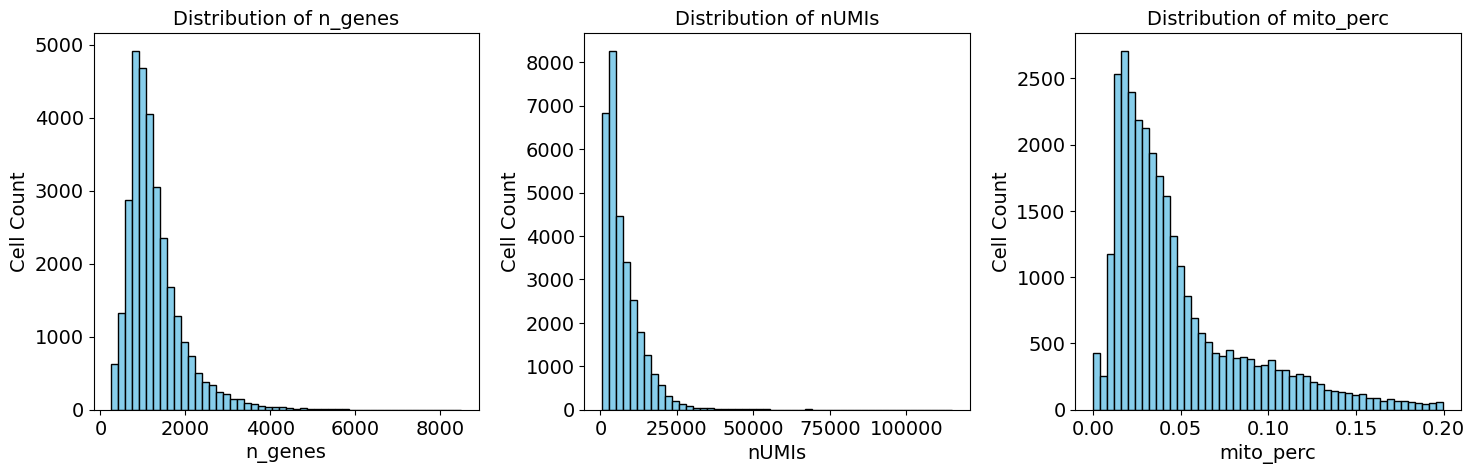

In [38]:
import matplotlib.pyplot as plt

# 选择要可视化的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 绘制各个指标的直方图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# 绘制每个质量控制指标的直方图
for i, metric in enumerate(qc_metrics):
    ax[i].hist(adata.obs[metric], bins=50, color='skyblue', edgecolor='black')
    ax[i].set_title(f'Distribution of {metric}')
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Cell Count')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


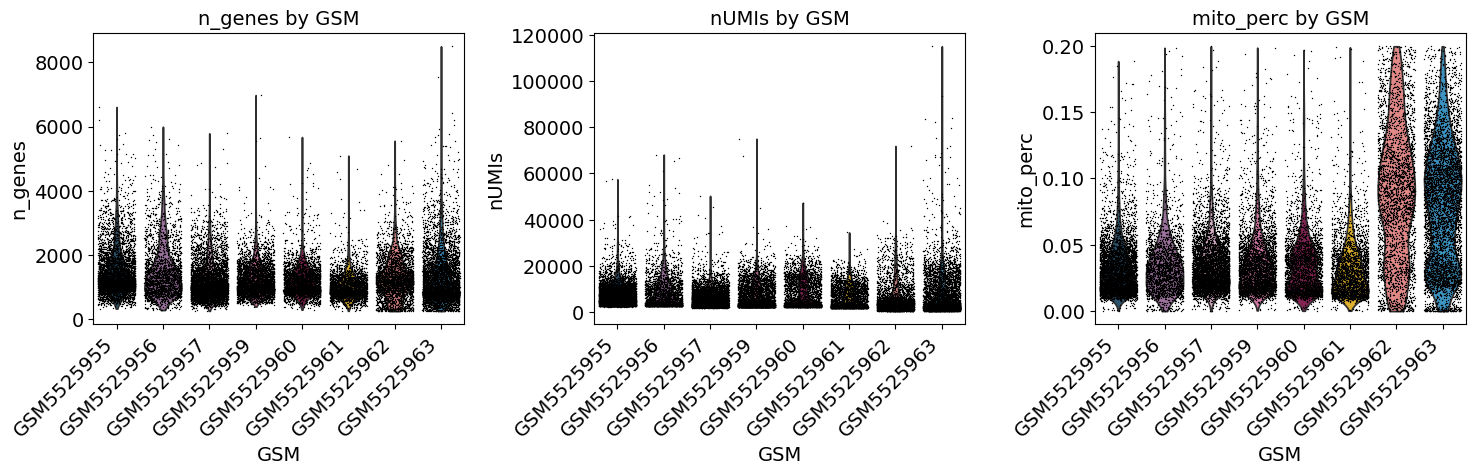

In [39]:
# 设置绘图风格
sc.settings.verbosity = 0  # 简化日志输出

# 选择要绘制的小提琴图的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 按照样本（GSM）绘制小提琴图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(qc_metrics):
    sc.pl.violin(adata, keys=metric, groupby='GSM', ax=ax[i], stripplot=True, jitter=0.4, show=False)
    ax[i].set_title(f'{metric} by GSM')
    ax[i].set_ylabel(f'{metric}')
    
    # 获取当前的x轴标签
    labels = ax[i].get_xticklabels()
    # 旋转标签并调整对齐方式（末尾对齐）
    ax[i].set_xticklabels(labels, rotation=45, ha='right')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


### 严格细胞质控标准
- min_genes = 200          # 最少基因数
- max_genes = 4000         # 最多基因数
- min_umis = 500           # 最少UMI数量
- max_umis = 20000         # 最多UMI数量
- max_mito_perc = 10       # 线粒体基因百分比最大值

In [40]:
# 设置阈值
min_genes = 200          # 最少基因数
max_genes = 6000         # 最多基因数
min_umis = 500           # 最少UMI数量
max_umis = 20000        # 最多UMI数量
max_mito_perc = 0.1       # 线粒体基因百分比最大值

# 根据阈值进行过滤
adata = adata[(adata.obs['n_genes'] > min_genes) & 
              (adata.obs['n_genes'] < max_genes) &
              (adata.obs['nUMIs'] > min_umis) &
              (adata.obs['nUMIs'] < max_umis) &
              (adata.obs['mito_perc'] < max_mito_perc), :]

# 输出过滤后的细胞数
print(f'Number of cells after filtering: {adata.n_obs}')

Number of cells after filtering: 26128


## 保存质控后数据


In [41]:
import os
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/03_qc_filtered/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "1_GSE182270_qc.h5ad"), compression='gzip')

## 降维聚类

In [42]:
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0
✅ plot_set complete.

CPU-GPU mixed mode activated


结肠组织细胞，所以选取2000个高变基因  
大致分别谱系，所以选取resolution=0.4

In [43]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.4)

Begin robust gene identification
After filtration, 15077/15077 genes are kept.     Among 15077 genes, 15072 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
['IGKC', 'JCHAIN', 'FTH1', 'MALAT1', 'IGHA2', 'IGHG4', 'IGHG2', 'IGHA1', 'IGHG3', 'IGHM', 'FTL', 'IGLL5', 'IGLC2', 'IGLC3', 'IGLC7']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 2.1700074672698975 seconds.
End of size normalization: shiftlog and HVGs

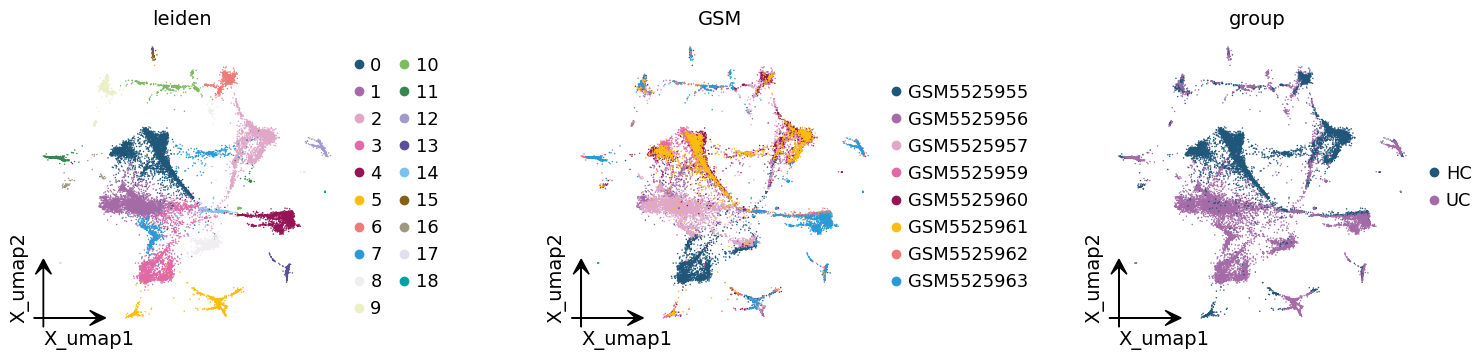

In [44]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

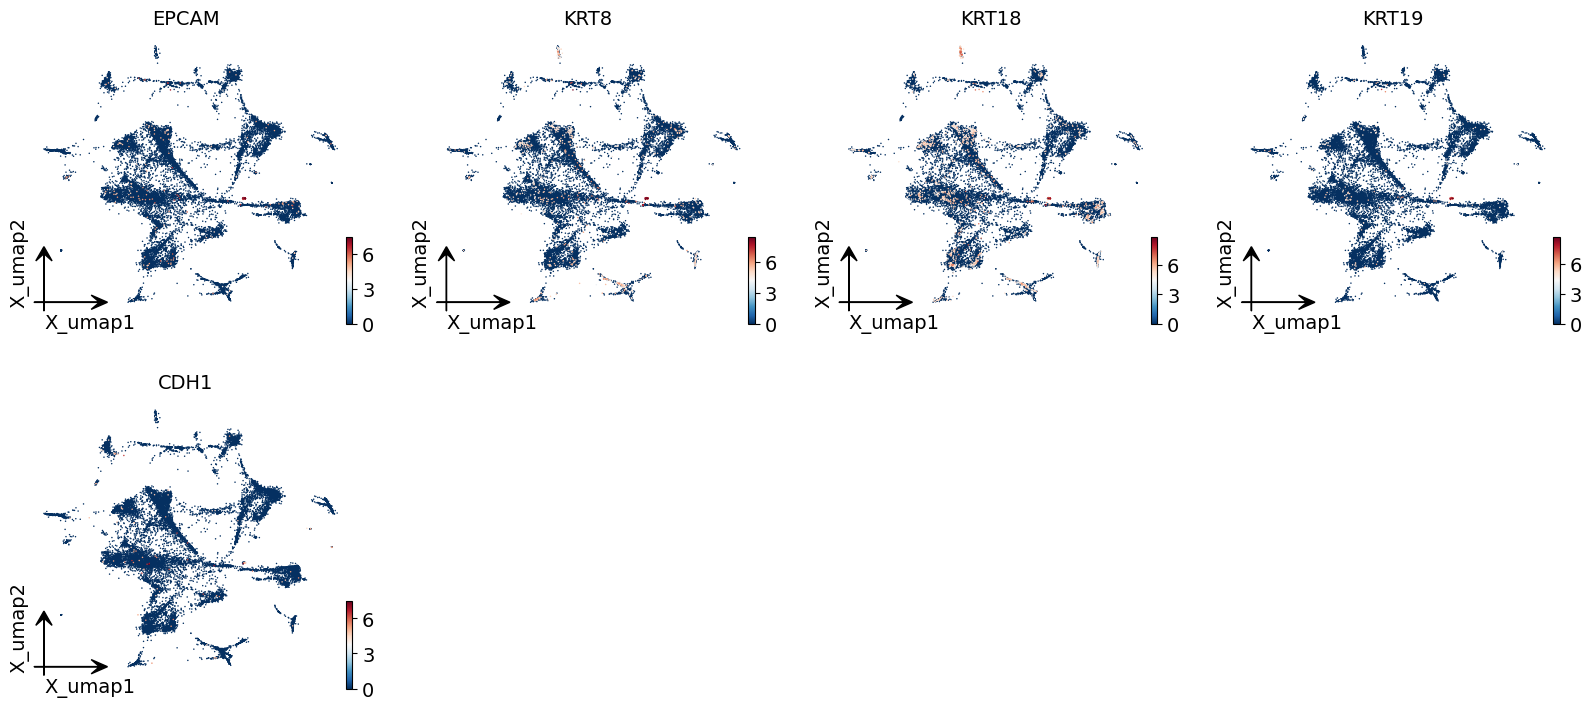

In [45]:
# 上皮谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1'], # CLDN1
                frameon='small')

几乎没有上面上皮细胞marker的表达

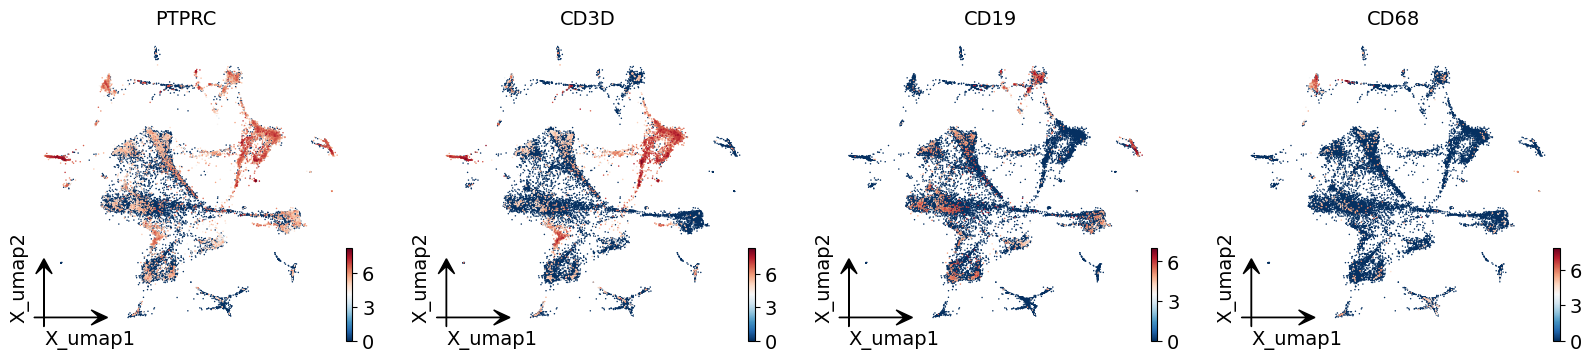

In [46]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

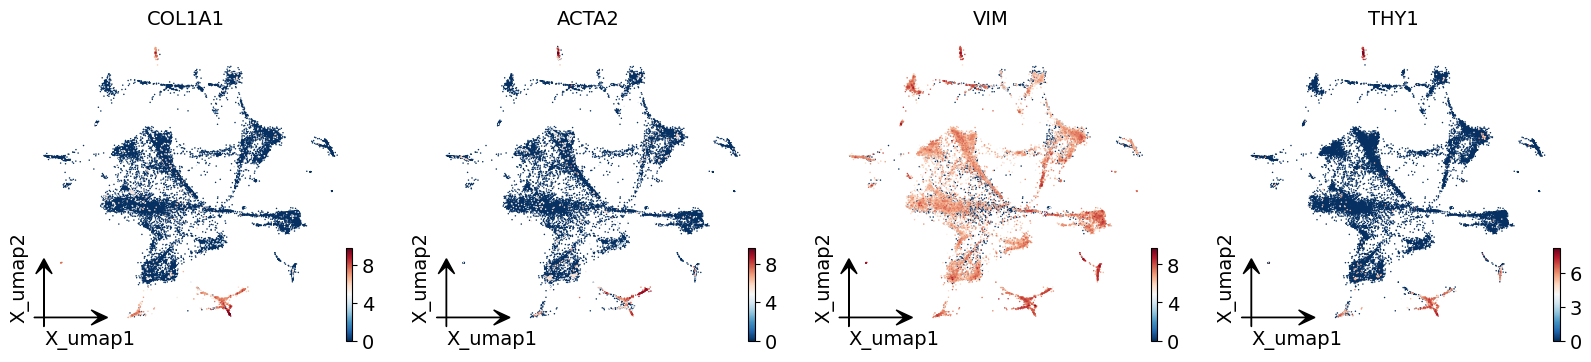

In [47]:
# 基质谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['COL1A1', 'ACTA2', 'VIM', 'THY1'],  # 'FAP'
                frameon='small')

## 去除批次效应
按样本去除批次，看看是否效果会更好

使用`harmony`

In [48]:
ov.single.batch_correction(adata,
                           batch_key='GSM', # 去批次分组标签
                           methods='harmony',
                           n_pcs=50)
                           
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='X_harmony')

ov.pp.umap(adata)

ov.pp.leiden(adata,resolution=0.4)

...Begin using harmony to correct batch effect


2025-11-04 13:45:40,297 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-04 13:45:42,794 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-04 13:45:42,890 - harmonypy - INFO - Iteration 1 of 10
2025-11-04 13:45:47,909 - harmonypy - INFO - Iteration 2 of 10
2025-11-04 13:45:52,958 - harmonypy - INFO - Iteration 3 of 10
2025-11-04 13:45:57,943 - harmonypy - INFO - Iteration 4 of 10
2025-11-04 13:46:02,886 - harmonypy - INFO - Iteration 5 of 10
2025-11-04 13:46:07,827 - harmonypy - INFO - Iteration 6 of 10
2025-11-04 13:46:12,167 - harmonypy - INFO - Iteration 7 of 10
2025-11-04 13:46:17,072 - harmonypy - INFO - Iteration 8 of 10
2025-11-04 13:46:22,078 - harmonypy - INFO - Iteration 9 of 10
2025-11-04 13:46:24,113 - harmonypy - INFO - Converged after 9 iterations


🖥️ Using Scanpy CPU to calculate neighbors...
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
🔍 [2025-11-04 13:46:26] Running UMAP in 'cpu-gpu-mixed' mode...
🚀 Using torch GPU to calculate UMAP...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    ||||||------------------------ 3353/16311 MiB (20.6%)
computing UMAP🚀
    finished ✅: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)
✅ UMAP completed successfully.
🖥️ Using Scanpy CPU Leiden...
running Leiden clustering
    finished: found 15 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:04)


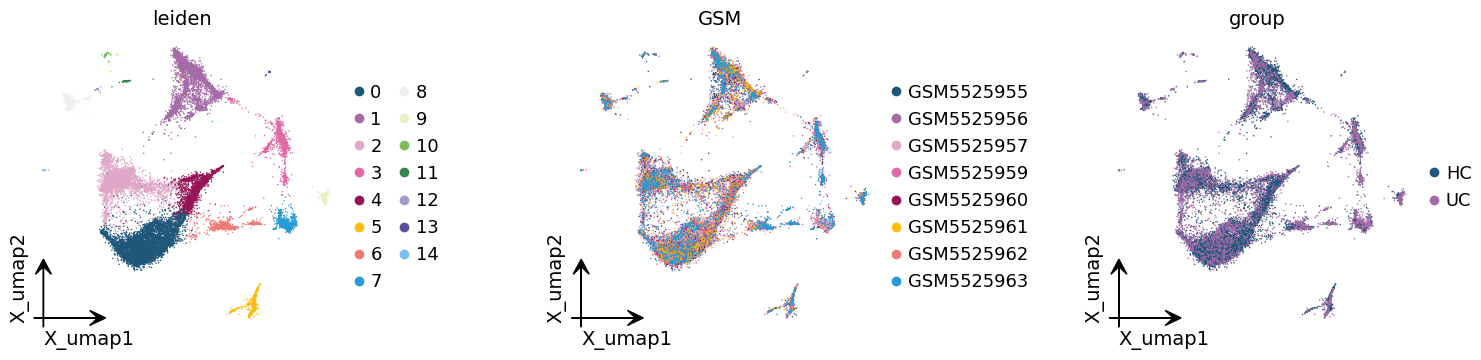

In [49]:
# 可视化查看去除批次效应后聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

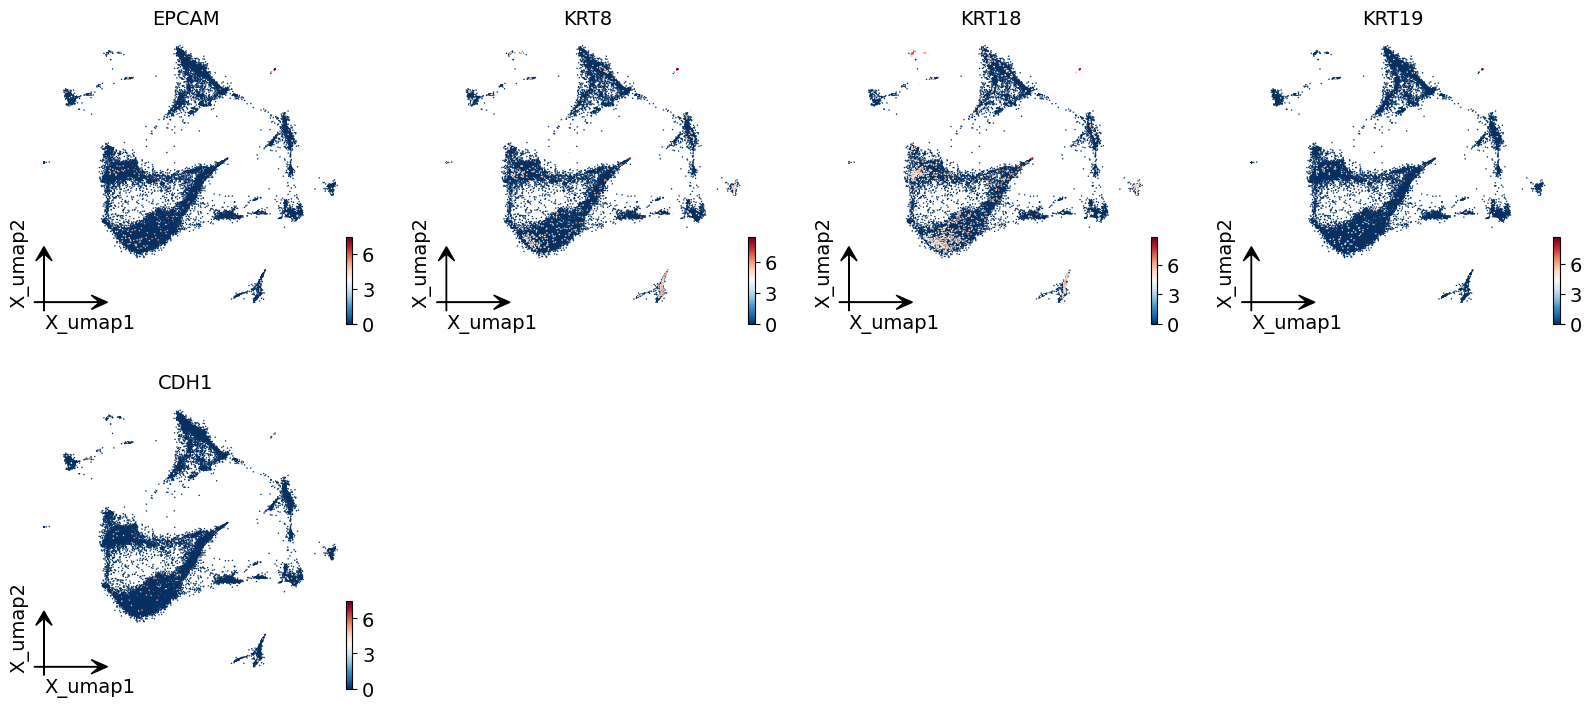

In [50]:
# 上皮谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1'], # CLDN1
                frameon='small')

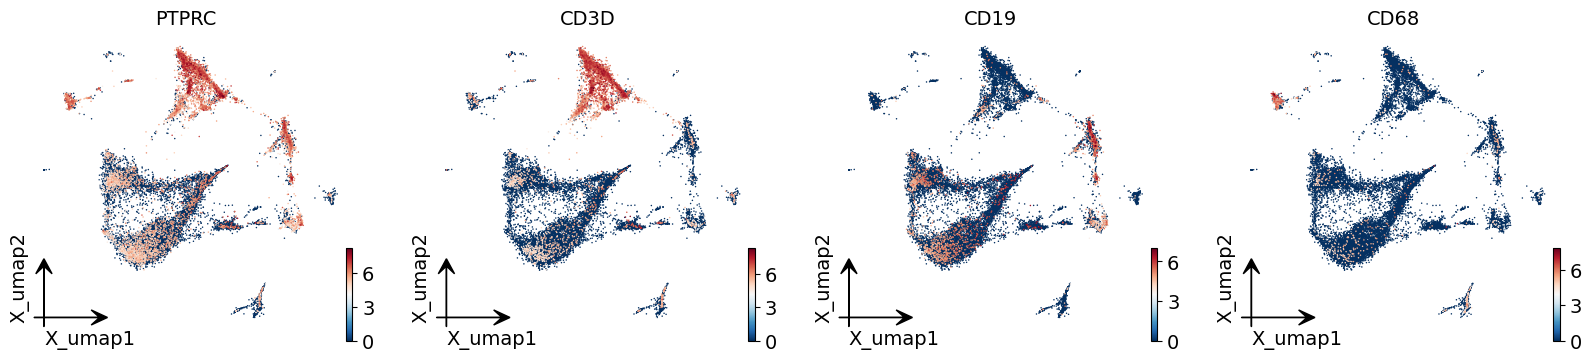

In [51]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

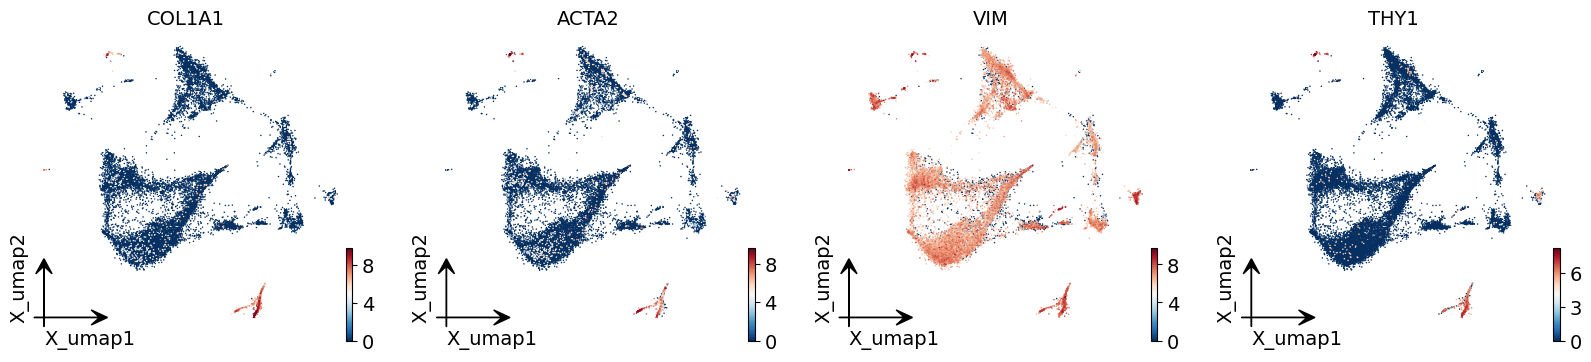

In [52]:
# 基质谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['COL1A1', 'ACTA2', 'VIM', 'THY1'],  # 'FAP'
                frameon='small')

运行harmony之后明显更加均匀，但是难以判断是否掩盖了部分差异，有待考虑

## GPT自动注释

In [53]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:08)


{'0': ['SSR4',
  'SPCS1',
  'JCHAIN',
  'CYBA',
  'SPCS2',
  'XBP1',
  'SEC11C',
  'HERPUD1',
  'IGHA1',
  'IGKC'],
 '1': ['IL32',
  'CD7',
  'IL7R',
  'CD3D',
  'TRAC',
  'CD2',
  'CD3E',
  'PTPRC',
  'BTG1',
  'TRBC2'],
 '10': ['IGFBP7',
  'CALD1',
  'SPARC',
  'COL4A2',
  'MGP',
  'COL4A1',
  'RGS5',
  'MYL9',
  'NDUFA4L2',
  'CAV1'],
 '11': ['NFKBIA',
  'CD52',
  'IL7R',
  'TRBC1',
  'LST1',
  'KLRB1',
  'TNFAIP3',
  'FXYD5',
  'AREG',
  'LTB'],
 '12': ['ID2',
  'FSCN1',
  'HLA-DPB1',
  'HLA-DPA1',
  'CCR7',
  'TMSB4X',
  'TMSB10',
  'TXN',
  'HLA-DRA',
  'ACTB'],
 '13': ['AGR2',
  'S100A10',
  'LGALS4',
  'KRT18',
  'PIGR',
  'KRT8',
  'TSPAN8',
  'KRT19',
  'PHGR1',
  'S100A6'],
 '14': ['GPM6B',
  'IGFBP7',
  'PRNP',
  'VIM',
  'SPARC',
  'CRYAB',
  'ALDH1A1',
  'MARCKS',
  'PMP22',
  'TUBA1A'],
 '2': ['IGLC3',
  'IGLC6',
  'SSR4',
  'FKBP2',
  'DERL3',
  'MZB1',
  'IGLC2',
  'IGLL1',
  'FKBP11',
  'IGLC7'],
 '3': ['CD52',
  'HLA-DQA1',
  'HLA-DPB1',
  'HLA-DQB1',
  'HLA-DPA1',
 

In [ ]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

In [46]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

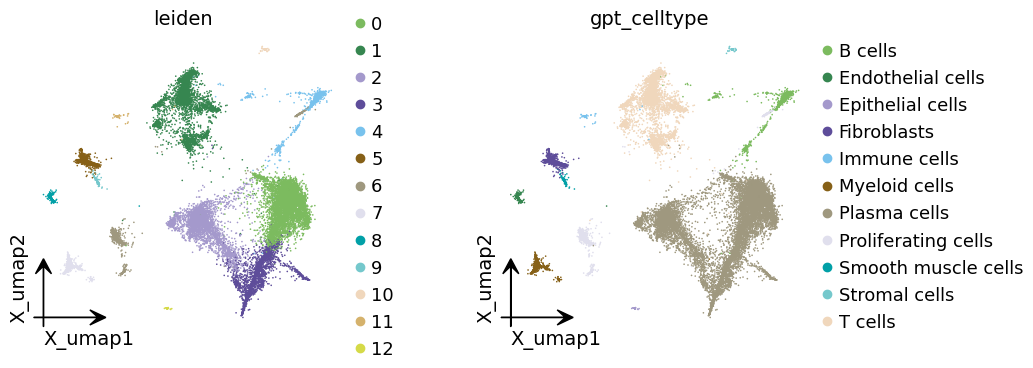

In [47]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [48]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
Plasma cells           54.289390
T cells                19.684786
B cells                 6.846483
Fibroblasts             5.104995
Proliferating cells     4.925791
Myeloid cells           3.914901
Endothelial cells       1.962046
Smooth muscle cells     1.079814
Stromal cells           0.928181
Immune cells            0.808712
Epithelial cells        0.454901
Name: proportion, dtype: float64


## 针对浆细胞的研究
浆细胞在所有细胞当中占比太高了，非常可疑

细胞群0、2、3被识别为浆细胞

### 查看B细胞和浆细胞marker的表达情况

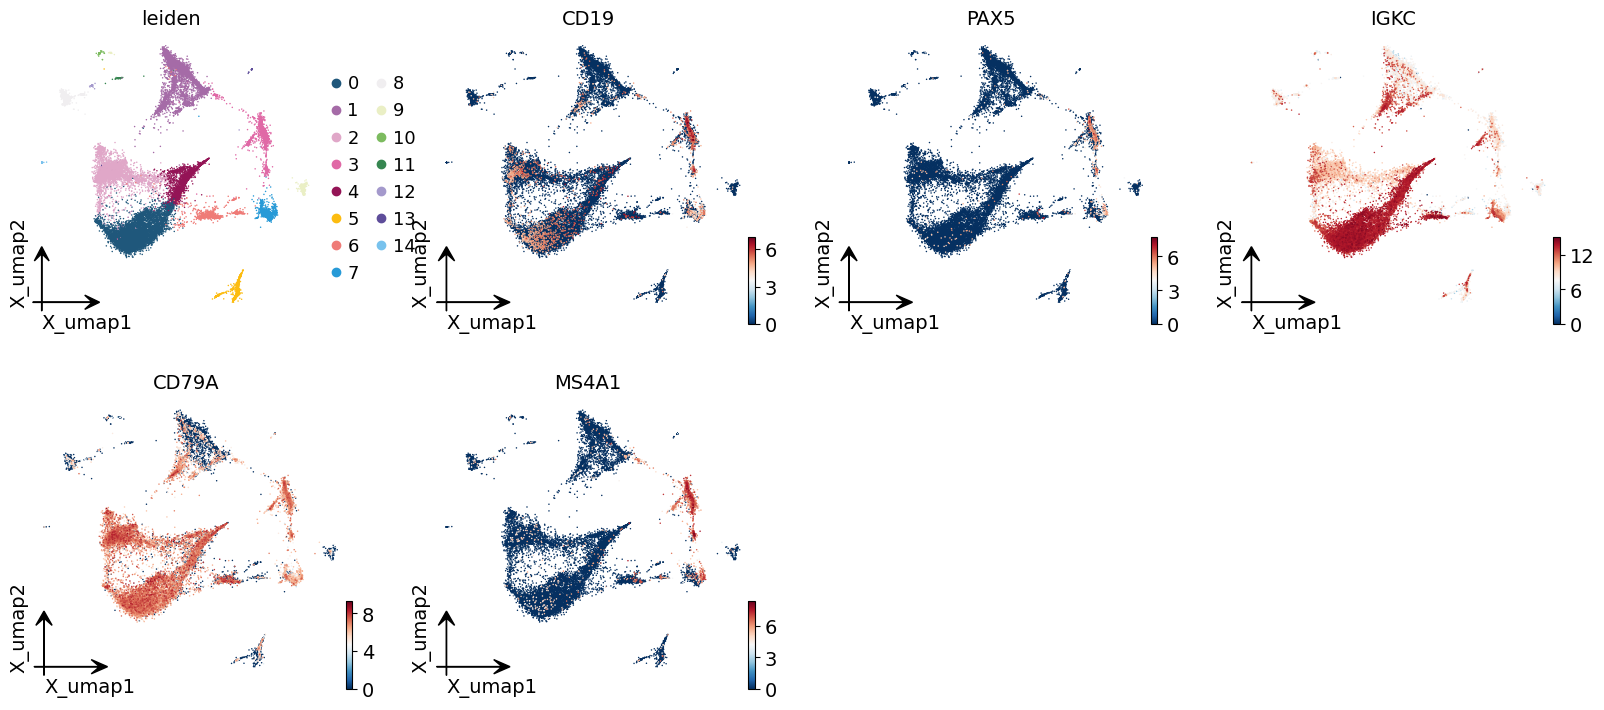

In [55]:
# B细胞marker
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'CD19', 'PAX5', 'IGKC', 'CD79A', 'MS4A1'], 
                frameon='small')

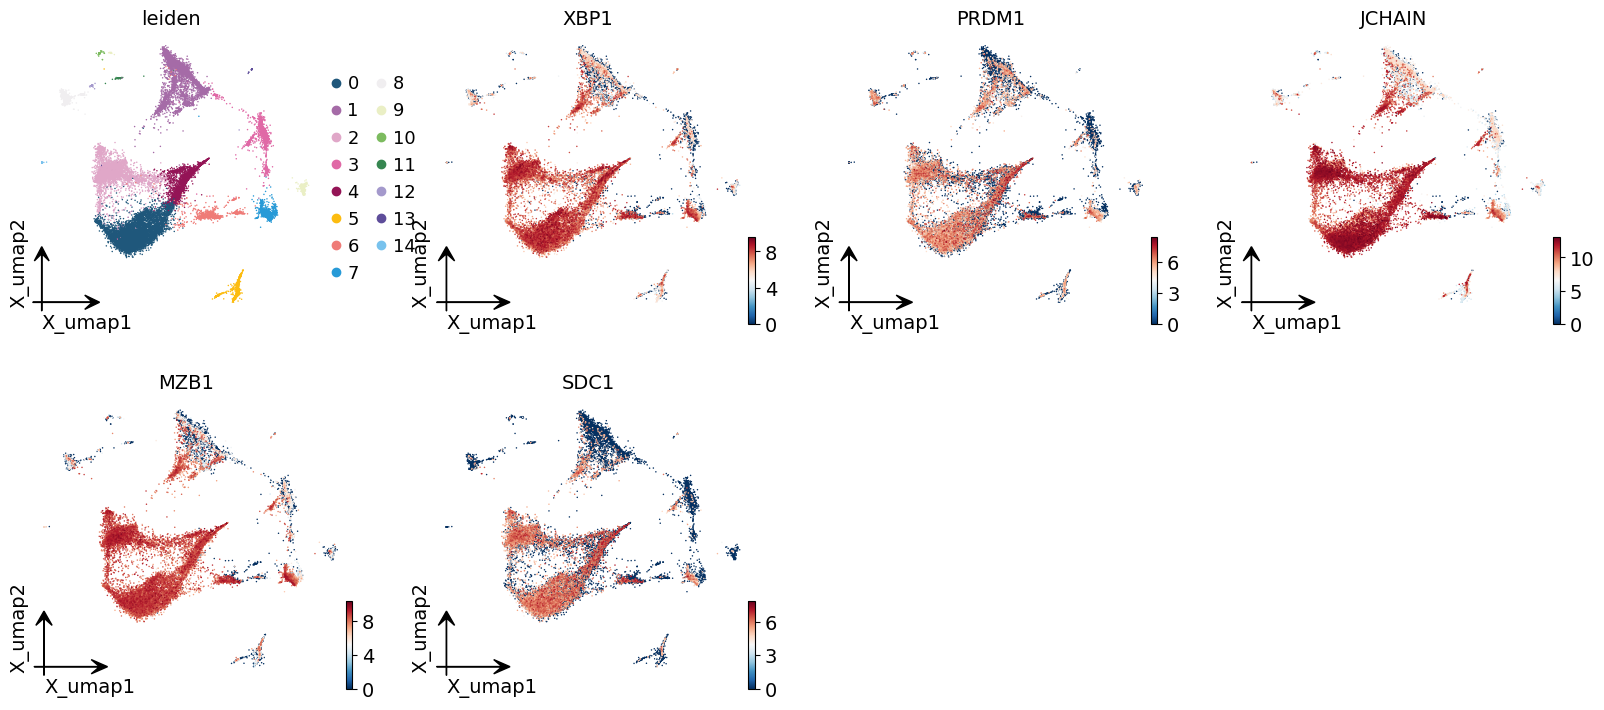

In [56]:
# 浆细胞marker
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'XBP1', 'PRDM1', 'JCHAIN', 'MZB1', 'SDC1'],  
                frameon='small')

# 总结：
- 去除批次效应后，细胞分布更加均匀，但UC和HC的分布差异减小了，但是总体当中还是有部分差异的，并且聚类质量提高了。所以该数据集值得以样本为单位去除批次
- 数量众多的浆细胞无特殊异常，但为什么占比这么高，需研究该数据集原论文